In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/transactions_flagged.csv', parse_dates=['date'])
sns.set_theme(style='darkgrid')
os.makedirs('../plots', exist_ok=True)

print(f"Loaded {len(df)} transactions ✅")
print(f"Anomalies flagged: {df['flag_combined'].sum()}")

Loaded 1079 transactions ✅
Anomalies flagged: 9


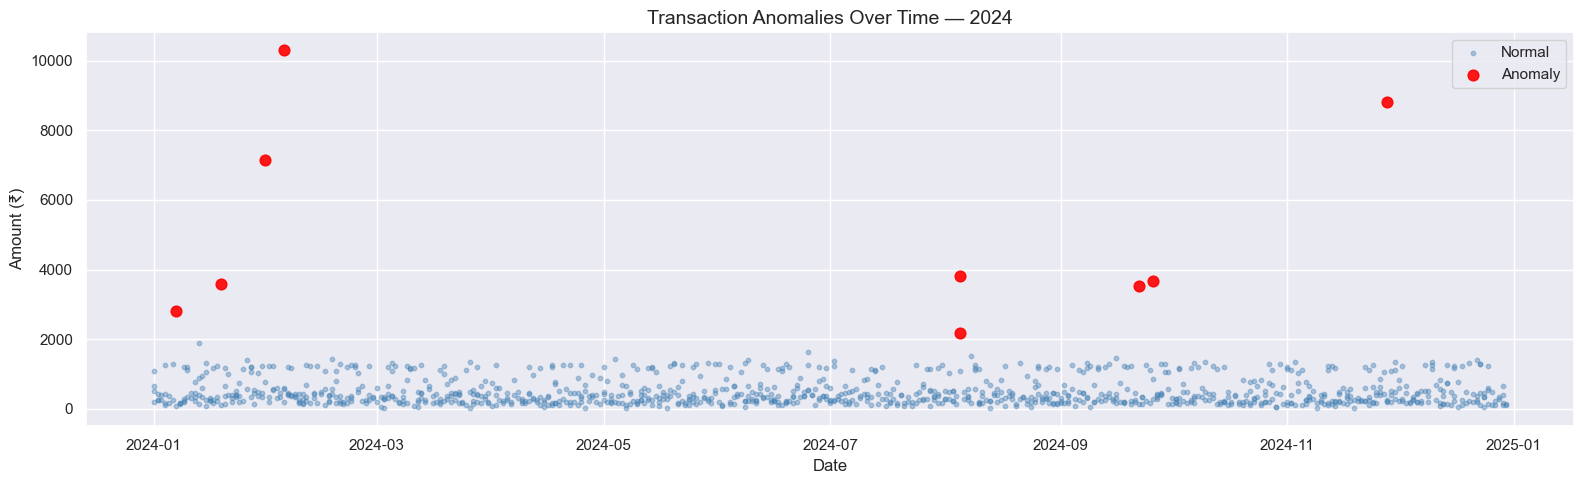

Plot saved ✅


In [2]:
normal    = df[df['flag_combined'] == 0]
anomalies = df[df['flag_combined'] == 1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.scatter(normal['date'], normal['amount'],
           alpha=0.4, s=10, color='steelblue', label='Normal')
ax.scatter(anomalies['date'], anomalies['amount'],
           alpha=0.9, s=60, color='red', label='Anomaly', zorder=5)
ax.set_title('Transaction Anomalies Over Time — 2024', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Amount (₹)')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/anomaly_timeseries.png', dpi=150)
plt.show()
print("Plot saved ✅")

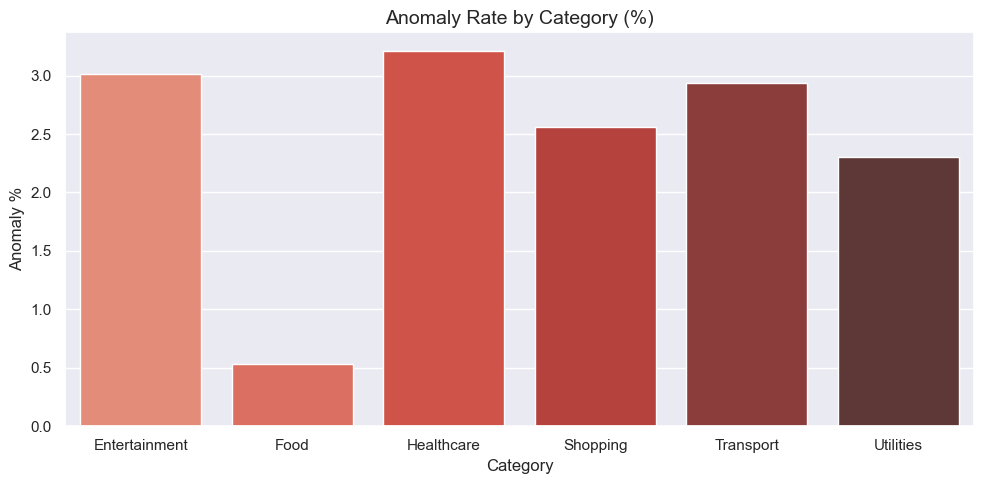

Plot saved ✅


In [3]:
cat_anomaly = df.groupby('category').agg(
    total=('flag_iqr', 'count'),
    anomalies=('flag_iqr', 'sum')
).reset_index()
cat_anomaly['rate'] = (cat_anomaly['anomalies'] / cat_anomaly['total'] * 100).round(2)

plt.figure(figsize=(10, 5))
sns.barplot(data=cat_anomaly, x='category', y='rate', 
            hue='category', palette='Reds_d', legend=False)
plt.title('Anomaly Rate by Category (%)', fontsize=14)
plt.ylabel('Anomaly %')
plt.xlabel('Category')
plt.tight_layout()
plt.savefig('../plots/anomaly_rate.png', dpi=150)
plt.show()
print("Plot saved ✅")

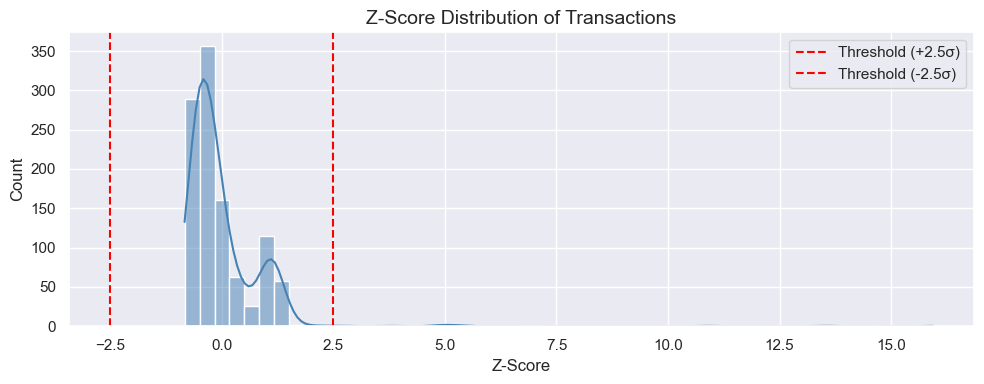

Plot saved ✅


In [4]:
plt.figure(figsize=(10, 4))
sns.histplot(df['z_score'], bins=50, kde=True, color='steelblue')
plt.axvline(2.5,  color='red', linestyle='--', label='Threshold (+2.5σ)')
plt.axvline(-2.5, color='red', linestyle='--', label='Threshold (-2.5σ)')
plt.title('Z-Score Distribution of Transactions', fontsize=14)
plt.xlabel('Z-Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/zscore_dist.png', dpi=150)
plt.show()
print("Plot saved ✅")

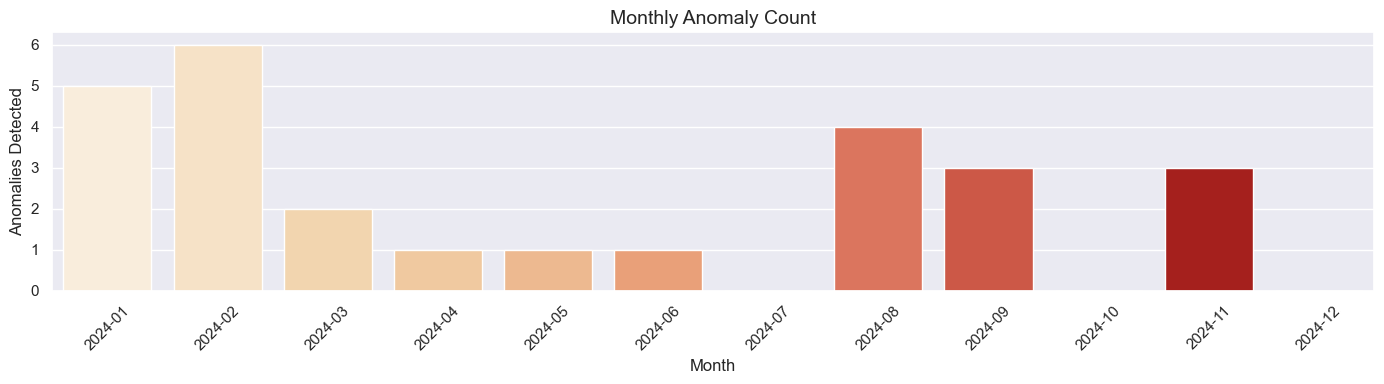

Plot saved ✅


In [5]:
df['month'] = df['date'].dt.to_period('M').astype(str)
monthly_anom = df.groupby('month')['flag_iqr'].sum().reset_index()
monthly_anom.columns = ['month', 'anomaly_count']

plt.figure(figsize=(14, 4))
sns.barplot(data=monthly_anom, x='month', y='anomaly_count',
            hue='month', palette='OrRd', legend=False)
plt.title('Monthly Anomaly Count', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Anomalies Detected')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/monthly_anomalies.png', dpi=150)
plt.show()
print("Plot saved ✅")